## Data exploration

In [69]:
# importing librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, log
from pandas.plotting import scatter_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.cluster  import  KMeans
from  sklearn.metrics  import confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVC
from sklearn.svm import SVR
from matplotlib.pyplot import table
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import f1_score
from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.linear_model import LassoCV, LassoLarsCV



# Lecture des données
## Charger les données ou les lire directement en précisant le chemin
hsd=pd.read_csv("healthcare_synthetic_data.csv",sep=",",header=0)
# Vérification de la forme des données
hsd.head()




,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [2]:
hsd.dtypes

Patient_ID                     str
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

In [3]:
"""AttributeErrorList of quantitative variables
Gender
Smoking_Status
Alcohol_Consumption
Physical_Activity_Level 
Family_History
Stress_Level"""

'AttributeErrorList of quantitative variables\nGender\nSmoking_Status\nAlcohol_Consumption\nPhysical_Activity_Level \nFamily_History\nStress_Level'

In [4]:
qualitative_var = ["Gender", "Smoking_Status", "Alcohol_Consumption", "Physical_Activity_Level", "Family_History", "Stress_Level"]

for i in qualitative_var:
    hsd[i]=pd.Categorical(hsd[i])

"""
hsd["Patient_ID"]=pd.Categorical(hsd["Patient_ID"])
hsd["Gender"]=pd.Categorical(hsd["Gender"],ordered=False)
hsd["Smoking_Status"]=pd.Categorical(hsd["Gender"], ordered=False)
hsd["Alcohol_Consumption"]=pd.Categorical(hsd["Alcohol_Consumption"], ordered=False)
"""

'\nhsd["Patient_ID"]=pd.Categorical(hsd["Patient_ID"])\nhsd["Gender"]=pd.Categorical(hsd["Gender"],ordered=False)\nhsd["Smoking_Status"]=pd.Categorical(hsd["Gender"], ordered=False)\nhsd["Alcohol_Consumption"]=pd.Categorical(hsd["Alcohol_Consumption"], ordered=False)\n'

In [5]:
hsd.dtypes

Patient_ID                      str
Age                           int64
Gender                     category
Height_cm                   float64
Weight_kg                   float64
BMI                         float64
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Fasting_Blood_Sugar           int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level               category
Sleep_Hours                   int64
Heart_Disease_Risk            int64
dtype: object

In [6]:
hsd.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Sleep_Hours,Heart_Disease_Risk
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,6.506067,0.436000
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,1.212626,0.495904
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,4.000000,0.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,6.000000,0.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,7.000000,0.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,7.000000,1.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,1.000000


### Exploration élémentaire

#### Statistiques unidimensionnelles

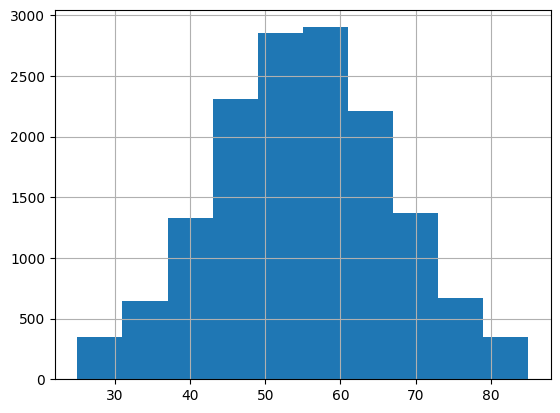

In [7]:
hsd["Age"].hist()
plt.show()

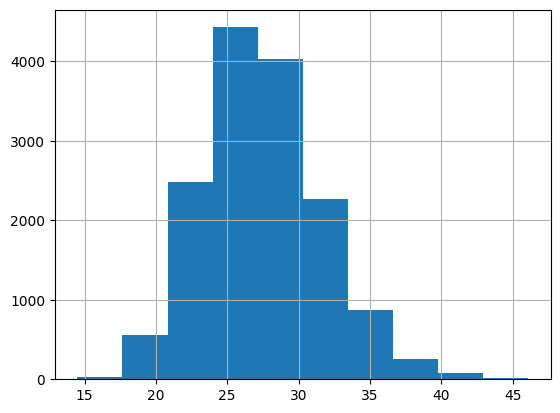

In [8]:
hsd["BMI"].hist()
plt.show()

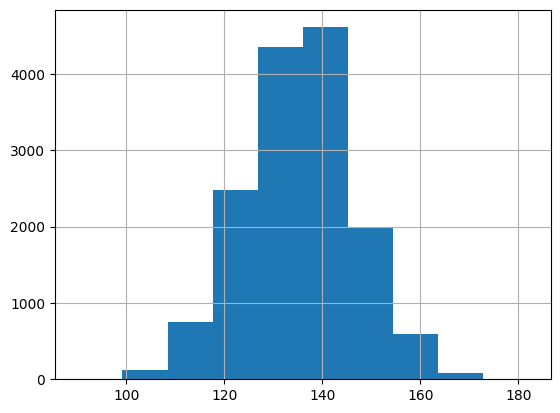

In [9]:
hsd["Systolic_BP"].hist()
plt.show()

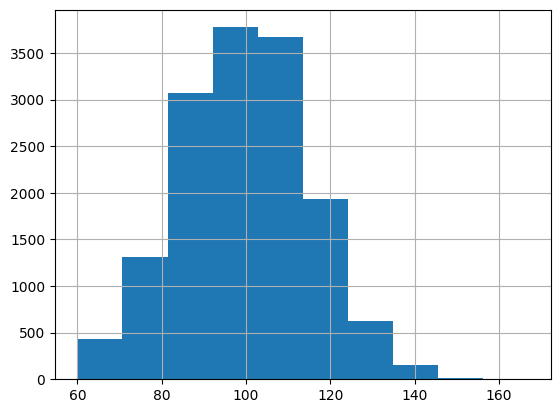

In [10]:
hsd["Fasting_Blood_Sugar"].hist()
plt.show()

In [11]:
hsd["LBMI"]=hsd["BMI"].map(lambda x: log(x))
hsd["LFBS"]=hsd["Fasting_Blood_Sugar"].map(lambda x: log(x))
del hsd["BMI"]
del hsd["Fasting_Blood_Sugar"]


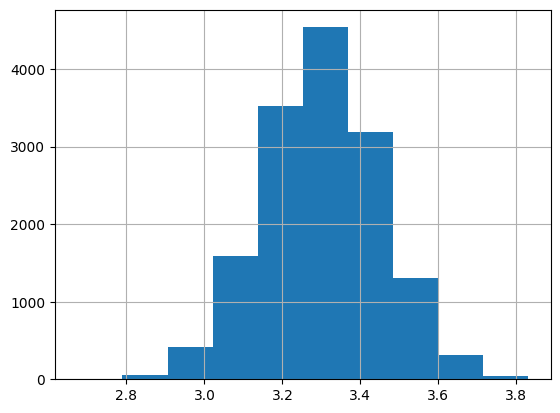

In [12]:
hsd["LBMI"].hist()
plt.show()

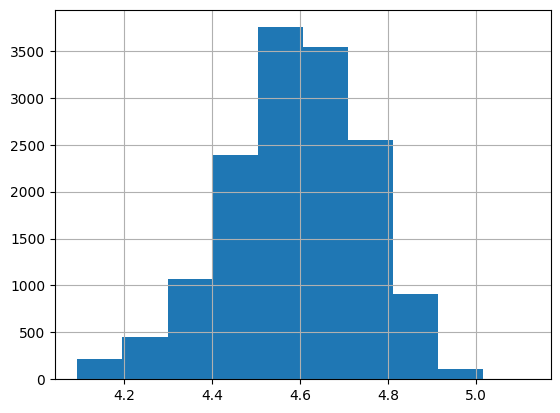

In [13]:
hsd["LFBS"].hist()
plt.show()

Analyse multidimensionnelle

In [14]:
"""from pandas.plotting import scatter_matrix
scatter_matrix(hsd[], alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.show()"""

"from pandas.plotting import scatter_matrix\nscatter_matrix(hsd[], alpha=0.2, \n               figsize=(15, 15), diagonal='kde')\nplt.show()"

This step is necessary to be able to make a realistic evaluation of our model and to make sure we do not have an overfitted model.

## Modelization

Our goal is to compare the performance of several modelization methods :
- Linear model (with/without : variable selection and penalization)
- SVR/SVM
- optimal tree
- random forest
- boosting
- neural networks

For each model we will identify the hyperparameters and adjust them with cross validation methods. 

#### Data set

In [15]:
hsd_clean = hsd.drop("Patient_ID",axis=1)

In [104]:
## Divide the dataset : train and test samples 

scaler = StandardScaler()  

### HEART DISEASE RISK
hsd_clean_copy= hsd_clean.copy()
y_heart= hsd_clean_copy["Heart_Disease_Risk"]
X_heart= hsd_clean_copy.drop("Heart_Disease_Risk",axis=1)
X_heart_train_unscaled, X_heart_test_unscaled, y_heart_train, y_heart_test = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)
# Normalisation des données
scaler.fit(X_heart)  
X_heart_train = pd.DataFrame(scaler.transform(X_heart_train_unscaled), columns=X_heart_test_unscaled.columns)
X_heart_test = pd.DataFrame(scaler.transform(X_heart_test_unscaled), columns=X_heart_test_unscaled.columns)

### CHOLESTEROL LEVEL
hsd_clean_copy= hsd_clean.copy()
y_chol= hsd_clean_copy["Cholesterol_LDL"]
X_chol= hsd_clean_copy.drop(["Cholesterol_LDL", "Heart_Disease_Risk"], axis=1)
X_chol_train, X_chol_test, y_chol_train, y_chol_test = train_test_split(X_chol, y_chol, test_size=0.2, random_state=42)
# Normalisation des données
scaler.fit(X_chol)  
X_chol_train = pd.DataFrame(scaler.transform(X_chol_train), columns=X_chol_test.columns)
X_chol_test = pd.DataFrame(scaler.transform(X_chol_test), columns=X_chol_test.columns)

This step is necessary to be able to make a realistic evaluation of our model and to make sure we do not have an overfitted model.

### 1. Linear model

To find the most performant linear model, we are going to be testing several configurations :

a) Model selection

b) Variable selection (AIC, BIC, pvalue)

c) Penalization (Lasso, Ridge, ElasticNet, None)

##### Model

Since the `Heart_Disease_Risk` is a qualitative variable (binary), we will use a logistic regression model. This variable measures the risk of having a heart disease, where over 0.5 we consider the patient to be at high risk and under 0.5 at low risk.

Since the `Cholesterol_LDL` is a quantitative variable, we will use a linear regression model. This variable measures the Low-Density Lipoprotein / "Bad" cholesterol in mg/dL.

##### Metrics

To quantify the performance of our models, we are going to be using the following metrics :
* Logistic Regression : accuracy, specificity, sensitivity, AUC, number of variables (complexity or our model)
* Linear Regression : MSE, RMSE, R2, MAE, number of variables (complexity or our model)

In [37]:
### HEART DISEASE RISK - logistic regression

# Fit the model + predict the classes

logi = LogisticRegression(max_iter=5000).fit(X_heart_train, y_heart_train)
y_pred_logi_class = logi.predict(X_heart_test)

print("---HEART DISEASE RISK---")
print(f"Logistic Regression Score : {logi.score(X_heart_test, y_heart_test)}")
print("Logistic Regression Accuracy:", accuracy_score(y_heart_test, y_pred_logi_class))
print("Logistic Regression AUC:", roc_auc_score(y_heart_test, y_pred_logi_class))
print("Logistic Regression Sensitivity (taux de vrais positifs):", confusion_matrix(y_heart_test, y_pred_logi_class)[1][1] / (confusion_matrix(y_heart_test, y_pred_logi_class)[1][0] + confusion_matrix(y_heart_test, y_pred_logi_class)[1][1]))
print("Logistic Regression Specificity (taux de vrais négatifs):", confusion_matrix(y_heart_test, y_pred_logi_class)[0][0] / (confusion_matrix(y_heart_test, y_pred_logi_class)[0][0] + confusion_matrix(y_heart_test, y_pred_logi_class)[0][1]))
print("Logistic Regression Number of Variables:", len(X_heart.columns))
print("F beta score:", f1_score(y_heart_test, y_pred_logi_class))

# classes équilibrées ?
print("Distribution of classes in the data set:")
print(y_heart_test.value_counts())

### CHOLESTEROL LEVEL - linear regression

# Fit the model + predict the values
linreg = LinearRegression().fit(X_chol_train, y_chol_train)
y_pred_linreg = linreg.predict(X_chol_test)

print("---CHOLESTEROL LEVEL---")
print(f"Linear Regression R^2 Score : {linreg.score(X_chol_test, y_chol_test)}")
print("Linear Regression MSE:", mean_squared_error(y_chol_test, y_pred_linreg))
print("Linear Regression RMSE:", sqrt(mean_squared_error(y_chol_test, y_pred_linreg)))
print("Linear Regression MAE:", mean_absolute_error(y_chol_test, y_pred_linreg))
print("Linear Regression Number of Variables:", len(X_chol.columns))




---HEART DISEASE RISK---
Logistic Regression Score : 0.7363333333333333
Logistic Regression Accuracy: 0.7363333333333333
Logistic Regression AUC: 0.7247889587789351
Logistic Regression Sensitivity (taux de vrais positifs): 0.6355283307810107
Logistic Regression Specificity (taux de vrais négatifs): 0.8140495867768595
Logistic Regression Number of Variables: 17
F beta score: 0.6772745818033455
Distribution of classes in the data set:
Heart_Disease_Risk
0    1694
1    1306
Name: count, dtype: int64
---CHOLESTEROL LEVEL---
Linear Regression R^2 Score : 0.6944886480979214
Linear Regression MSE: 95.72360092376246
Linear Regression RMSE: 9.783843872617881
Linear Regression MAE: 7.724300316059042
Linear Regression Number of Variables: 16


RISK OF HEART DISEASE : With logisitc regression, we seem to get an appropriate model overall, with an AUC of about 72%. This shows a good ability to distinguish our data points between the two classes and therefore predict if there is a risk of heart desease based on several patient features. We want to control the risk of not diagnosting a patient that has a risk of heart disease. With a sensitivity of 0.63, we know that 37% of patients with heart disease risk are not diagnosed, which is a pretty high amount of missed predictions. On the contrary, with a specificity of 0.82, we predict the absence of risk to 82% of the healthy patients.

CHOLESTEROL LEVEL : Our linear regression model has a mean squared error of arounf 95%, which is an indicator of a high ability to predict closely enough the cholesterol level. However, we have a R2 of around 0.7 which shows that there is a bit of overfitting which might compromise the truthfulness of our high MSE value.

To make the accuracy analysis more robust, we can also use k-fold cross-validation. Instead of evaluating the model on a single train-test split, cross-validation repeatedly divides the data into different training and validation subsets and averages the results. This gives a more reliable estimate of model performance and reduces the risk that the conclusion depends too strongly on one particular split of the dataset.

##### Hyperparameter tuning the regularization parameter C

We are going to test our model on several values of C, the inverse of the regularization strength. 

Regularization penalizes large coefficients to avoid overfitting.
* If C is small, the model is more constrained, coefficients stay smaller, and the model is simpler.
* If C is large, the penalty is weaker, so the model can fit the training data more closely.

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

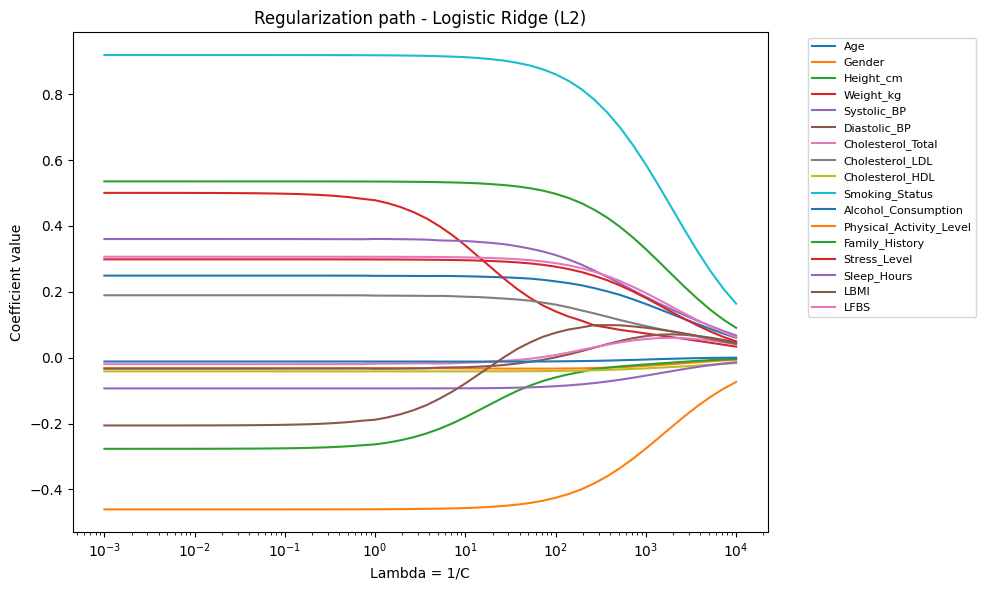

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rat

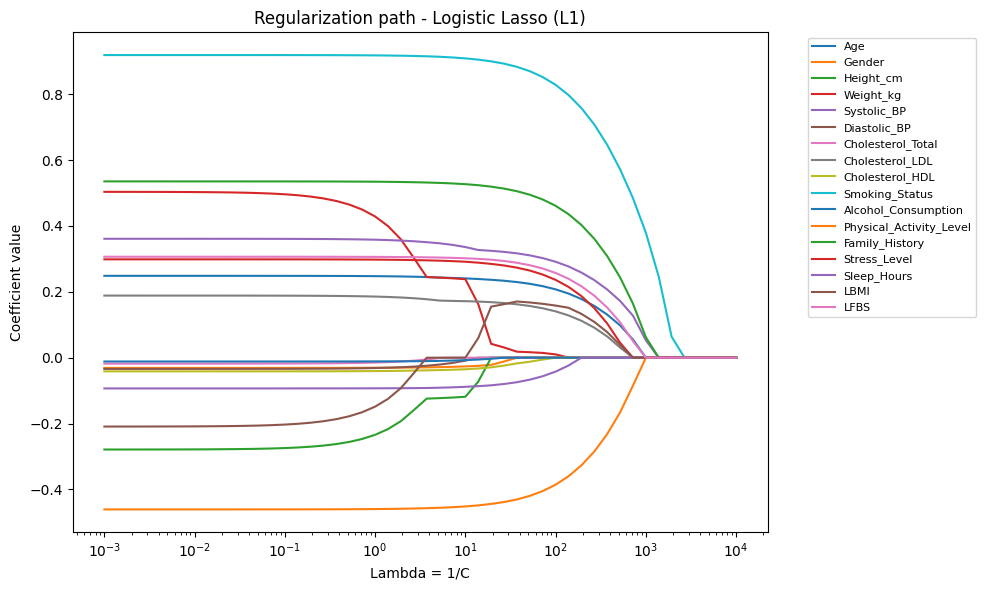

In [ ]:
def penalization_path_logistic(X_train, y_train):

    feature_names = X_train.columns

    # Grid of C values
    C_values = np.logspace(-4, 3, 50)   # from strong to weak regularization
    lambda_values = 1 / C_values        # equivalent inverse regularization scale

    list_penalization_methods = ["Ridge (L2)", "Lasso (L1)", "ElasticNet"] 
    
    for method in list_penalization_methods:
        coefs = []

        for C in C_values:
            model = LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                C=C,
                max_iter=5000,
                random_state=42
            )
            model.fit(X_heart_train, y_heart_train)
            coefs.append(model.coef_[0])

        coefs = np.array(coefs)

        plt.figure(figsize=(10, 6))
        for i in range(coefs.shape[1]):
            plt.plot(lambda_values, coefs[:, i], label=feature_names[i])

        plt.xscale("log")
        plt.xlabel("Lambda = 1/C")
        plt.ylabel("Coefficient value")
        plt.title("Regularization path - Logistic Ridge (L2)")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
        plt.tight_layout()
        plt.show()


##### Balancing classes

In [ ]:
pipeline = Pipeline([("model", LogisticRegression(max_iter=5000,class_weight='balanced'))])
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
print("BALANCED : Mean CV AUC:", scores.mean())

pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000))])
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
print("UNBALANCED : Mean CV AUC:", scores.mean())

BALANCED : Mean CV AUC: 0.8077619692620477
UNBALANCED : Mean CV AUC: 0.8077619678848824


Adding ``class_weight="balanced"`` did not improve the cross-validated AUC. The unweighted logistic regression achieved a slightly higher mean CV AUC, although the difference is negligible. This suggests that class imbalance is not a major issue for this model, or that reweighting does not bring additional predictive benefit in terms of discrimination.

#### b. Variable Selection

In this section we are going to use variable selection to get a more simple and interpretable model, even if we are aware that it could also be more unstable and overfit.

Hence we are going to determine a subset of predictors by adding and removing variables based on several citeria:
- AIC
- BIC
- p-values


##### i) AIC

In [129]:
# AIC Algorithm (Forward-Backward) - returns the selected variables
def stepwise_aic_FB(X, y, model_given):

    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    print(f"model_given : {model_given}")

    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_aic = float("inf")
        # for every variable that has been excluded we find the one with the lowest AIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.aic < best_aic:
                best_aic = model.aic
                best_feature = new_col
        # we check if by adding the best selected variable we get a lower aic
        if best_aic < model_given(y, sm.add_constant(X[included])).fit(disp=0).aic:
            included.append(best_feature)
            changed = True
            
        # Backward step
        # we determine the variable that has a higher pvalue (which is the least significant)
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst = pvals.idxmax()
            new_aic = model_given(y, sm.add_constant(X[[c for c in included if c != worst]])).fit(disp=0).aic
            # we remove the selected variable if the aic is lower when we remove it
            if new_aic < model.aic:
                included.remove(worst)
                changed = True
        if not changed:
            break
    return included



##### ii) BIC

In [130]:
# BIC Algorithm (Forward-Backward) - returns the selected variables
def stepwise_bic_FB(X, y, model_given):

    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    included = [] 
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        best_bic = float("inf")
        # for every variable that has been excluded we find the one with the lowest BIC
        for new_col in excluded: 
            model = model_given(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            if model.aic < best_bic:
                best_bic = model.bic
                best_feature = new_col
        # we check if by adding the best selected variable we get a lower aic
        if best_bic < model_given(y, sm.add_constant(X[included])).fit(disp=0).bic:
            included.append(best_feature)
            changed = True
            
        # Backward step
        # we determine the variable that has a higher pvalue (which is the least significant)
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst = pvals.idxmax()
            new_bic = model_given(y, sm.add_constant(X[[c for c in included if c != worst]])).fit(disp=0).bic
            # we remove the selected variable if the aic is lower when we remove it
            if new_bic < model.bic:
                included.remove(worst)
                changed = True
        if not changed:
            break
    return included


##### iii) p-value


In [131]:
# P-value Algorithm (Forward-Backward) - returns the selected variables

def stepwise_pval_FB(X, y, model_given, entry_p=0.05, stay_p=0.05):
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    included = []
    while True:
        changed = False

        ### FORWARD step
        excluded = list(set(X.columns) - set(included))
        best_pval = 1.0
        for col in excluded:
            model = model_given(y, sm.add_constant(X[included + [col]])).fit(disp=0)
            pval = model.pvalues[col]
            # we look for the varible with the lowest p-value
            if pval < best_pval:
                best_pval = pval
                best_feature = col
        # we check if adding the best selected variable gives us a p-value lower than the entry threshold
        if best_pval < entry_p:
            included.append(best_feature)
            changed = True

        ### BACKWARD step
        if included:
            model = model_given(y, sm.add_constant(X[included])).fit(disp=0)
            pvals = model.pvalues.drop("const")
            worst_pval = pvals.max()
            # we remove the variable with the highest p-value if it is higher than the stay threshold
            if worst_pval > stay_p:
                worst_feature = pvals.idxmax()
                included.remove(worst_feature)
                changed = True

        # we stop the algorithm if no variable is added or removed
        if not changed:
            break
        
    return included




In [132]:
def lasso_var_sel(X_train, y_train, model_given, graphs=False):

    if model_given == sm.Logit:
        # Binary classification with L1 penalty
        logit_lasso = LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=5000
        )
        logit_lasso.fit(X_train, y_train)
        coef = pd.Series(logit_lasso.coef_[0], index=X_train.columns)

        if graphs==True:
            imp_coef = coef.sort_values()
            plt.rcParams['figure.figsize'] = (8.0, 10.0)
            imp_coef.plot(kind = "barh")
            plt.title(u"Coefficients du modèle lasso pour la régression logistique")
            plt.show()

    elif model_given == sm.OLS:
        # Linear regression with L1 penalty
        lasso = Lasso(alpha=0.01, max_iter=5000)
        lasso.fit(X_train, y_train)
        coef = pd.Series(lasso.coef_, index=X_train.columns)

        if graphs==True:
            imp_coef = coef.sort_values()
            plt.rcParams['figure.figsize'] = (6.0, 6.0)
            imp_coef.plot(kind = "barh")
            plt.title(u"Coefficients du modèle lasso pour la régression linéaire")
            plt.show()

    else:
        raise ValueError("model_given must be sm.Logit or sm.OLS")

    return coef.index[coef != 0].tolist()


##### Variable selection algorithm comparison : AIC, BIC, p-value

In [133]:
def variable_selection(X_train, y_train, X_test, y_test, model, model_given):

    # Selected variables
    selected_variables_AIC = stepwise_aic_FB(X_train, y_train, model_given)
    selected_variables_BIC = stepwise_bic_FB(X_train, y_train, model_given)
    selected_variables_pval = stepwise_pval_FB(X_train, y_train, model_given)
    selected_variables_lasso = lasso_var_sel(X_train, y_train, model_given)

    # AIC Data set
    X_train_AIC = X_train[selected_variables_AIC]
    X_test_AIC = X_test[selected_variables_AIC] 
    X_train_BIC = X_train[selected_variables_BIC]
    X_test_BIC = X_test[selected_variables_BIC]
    X_train_pval = X_train[selected_variables_pval]
    X_test_pval = X_test[selected_variables_pval]
    X_train_lasso = X_train[selected_variables_lasso]
    X_test_lasso = X_test[selected_variables_lasso]


    # FIT

    pipeline_aic = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_bic = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_pval = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('logi', clone(model))
    ])

    pipeline_aic.fit(X_train_AIC, y_train)
    pipeline_bic.fit(X_train_BIC, y_train)
    pipeline_pval.fit(X_train_pval, y_train)
    pipeline_lasso.fit(X_train_lasso, y_train)

    print(f"\n---{model}---")

    if model_given == sm.Logit:
        
        print(f"\nWITHOUT VARIABLE SELECTION : AUC (test set) : {roc_auc_score(y_test, model.fit(X_train, y_train).predict_proba(X_test)[:,1])}")

        # SCORE
        y_pred_proba = pipeline_aic.predict_proba(X_test_AIC)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"AIC : {model} AUC (test set):", auc)

        y_pred_proba = pipeline_bic.predict_proba(X_test_BIC)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"BIC : {model} AUC (test set):", auc)

        y_pred_proba = pipeline_pval.predict_proba(X_test_pval)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"PVALUE : {model} AUC (test set):", auc)

        y_pred_proba = pipeline_lasso.predict_proba(X_test_lasso)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"Lasso : {model} AUC (test set):", auc)

    else:

        print(f"\nWITHOUT VARIABLE SELECTION : MSE (test set) : {mean_squared_error(y_test, model.fit(X_train, y_train).predict(X_test))}")

        MSE_AIC = mean_squared_error(y_test, pipeline_aic.predict(X_test_AIC))
        print(f"AIC : {model} MSE (test set):", MSE_AIC)

        MSE_BIC = mean_squared_error(y_test, pipeline_bic.predict(X_test_BIC))
        print(f"BIC : {model} MSE (test set):", MSE_BIC)

        MSE_PVAL = mean_squared_error(y_test, pipeline_pval.predict(X_test_pval))
        print(f"PVALUE : {model} MSE (test set):", MSE_PVAL)

        MSE_LASSO = mean_squared_error(y_test, pipeline_lasso.predict(X_test_lasso))
        print(f"Lasso : {model} MSE (test set):", MSE_LASSO)

    print("\nSelected variables:")
    print("Selected variables AIC:", selected_variables_AIC)
    print("Selected variables BIC:", selected_variables_BIC)
    print("Selected variables P-value:", selected_variables_pval)
    print("Selected variables Lasso:", selected_variables_lasso)


    return selected_variables_AIC, selected_variables_BIC, selected_variables_pval, selected_variables_lasso

selected_variables_AIC_heart, selected_variables_BIC_heart, selected_variables_pval_heart, selected_variables_lasso_heart = variable_selection(X_heart_train, y_heart_train, X_heart_test, y_heart_test, LogisticRegression(max_iter=5000), sm.Logit)
selected_variables_AIC_chol, selected_variables_BIC_chol, selected_variables_pval_chol, selected_variables_lasso_chol = variable_selection(X_chol_train, y_chol_train, X_chol_test, y_chol_test, LinearRegression(), sm.OLS)



# sm:Logit and sm.OLS are the model_given for logistic regression and linear regression respectively from the statsmodels library

model_given : <class 'statsmodels.discrete.discrete_model.Logit'>


c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



---LogisticRegression(max_iter=5000)---

WITHOUT VARIABLE SELECTION : AUC (test set) : 0.805881401071433
AIC : LogisticRegression(max_iter=5000) AUC (test set): 0.805823092402516
BIC : LogisticRegression(max_iter=5000) AUC (test set): 0.7929933772200235
PVALUE : LogisticRegression(max_iter=5000) AUC (test set): 0.805423067813434
Lasso : LogisticRegression(max_iter=5000) AUC (test set): 0.8058434326358592

Selected variables:
Selected variables AIC: ['Smoking_Status', 'Family_History', 'Systolic_BP', 'Physical_Activity_Level', 'LFBS', 'Stress_Level', 'Cholesterol_LDL', 'LBMI', 'Age', 'Sleep_Hours', 'Cholesterol_HDL']
Selected variables BIC: ['Smoking_Status', 'Family_History', 'Systolic_BP', 'Physical_Activity_Level', 'LFBS', 'Stress_Level']
Selected variables P-value: ['Smoking_Status', 'Family_History', 'Systolic_BP', 'Physical_Activity_Level', 'LFBS', 'Stress_Level', 'Cholesterol_LDL', 'LBMI', 'Age', 'Sleep_Hours']
Selected variables Lasso: ['Age', 'Gender', 'Height_cm', 'Weight_kg'

##### Best variable selection method?
HEART DISEASE RISK :
We get very similar AUC scores for the three methods. Even though BIC offers a lower AUC score (0.01 after AIC and pvalue), the selected model only has 7 variables (AIC : 10 | p-value : 11), which is very convenient for complexity matters. Therefore, BIC may be preferred for interpretability and model simplicity.

CHOLESTEROL LEVEL :
We get very similar MSE scores for the three methods. Even though BIC offers a lower MSE score (0.01 after AIC and pvalue), the selected model only has 2 variables (AIC : 5 | p-value : 3), which is very convenient for complexity matters. Therefore, BIC may be preferred for interpretability and model simplicity.

#### With or without variable selection ?

The linear model with logistic regression got a slightly hiher AUC score with the variable selection methods, passing from 0.80 to 0.81 and 0.82 depending on the chosen criterion. Therefore we will from now on consider the new selected model by the BIC criterion, which only takes into account the following 7 significative variables : 'Smoking_Status', 'Systolic_BP', 'Family_History', 'Physical_Activity_Level', 'LFBS', 'Stress_Level', 'Cholesterol_Total'.

##### c) Penalization

We are going to test how our model behaves when we add penalizations to it.

We will use Lasso (L1), Ridge (L2) and ElasticNet penalizations, three regularization techniques used to prevent overfitting by penalizing large coefficients. Lasso adds the absolute value of coefficients as a penalty, setting some to exactly zero for feature selection. Ridge adds the squared magnitude, shrinking coefficients toward zero but not removing variables. ElasticNet is a combination of Lasso and Ridge.


In [53]:
# No Penalty 
logi_none = LogisticRegression(max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_none = LinearRegression().fit(X_chol_train, y_chol_train)
# Lasso (L1 only)
logi_l1 = LogisticRegression(l1_ratio=1.0, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_l1 = Lasso(alpha=1.0).fit(X_chol_train, y_chol_train)
# Ridge (L2 only)
logi_l2 = LogisticRegression(l1_ratio=0.0, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_l2 = Ridge(alpha=1.0).fit(X_chol_train, y_chol_train)
# ElasticNet (balanced L1 + L2)
logi_elastic = LogisticRegression(l1_ratio=0.5, max_iter=5000, solver='saga').fit(X_heart_train, y_heart_train)
linreg_elastic = ElasticNet(alpha=1.0).fit(X_chol_train, y_chol_train)

#--> we add the saga solver as lbfgs does not support elasticnet and lasso penalties
#--> we leave C=1 as default but it can be tuned to find the best value for each penalty

print("---HEART DISEASE---")
print(f"Logistic Regression Score (No Penalty) : {logi_none.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (Lasso) : {logi_l1.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (Ridge) : {logi_l2.score(X_heart_test, y_heart_test)}")
print(f"Logistic Regression Score (ElasticNet) : {logi_elastic.score(X_heart_test, y_heart_test)}")
print("\n---CHOLESTEROL LEVEL---")
print(f"Linear Regression MSE Score (No Penalty) : {mean_squared_error(y_chol_test, linreg_none.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (Lasso) : {mean_squared_error(y_chol_test, linreg_l1.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (Ridge) : {mean_squared_error(y_chol_test, linreg_l2.predict(X_chol_test))}")
print(f"Linear Regression MSE Score (ElasticNet) : {mean_squared_error(y_chol_test, linreg_elastic.predict(X_chol_test))}")


---HEART DISEASE---
Logistic Regression Score (No Penalty) : 0.7366666666666667
Logistic Regression Score (Lasso) : 0.736
Logistic Regression Score (Ridge) : 0.7366666666666667
Logistic Regression Score (ElasticNet) : 0.736

---CHOLESTEROL LEVEL---
Linear Regression MSE Score (No Penalty) : 95.72360092376246
Linear Regression MSE Score (Lasso) : 96.27900701427873
Linear Regression MSE Score (Ridge) : 95.7235733675313
Linear Regression MSE Score (ElasticNet) : 121.2112549331591


We get nearly equivalent scores, with Ridge, ElasticNet and no penalty being the most performant penalizations with C=1 set by default. However, we want to check if when choosing the optimal C for each method, we get the same results. For this matter we are going to put in a place a GridSearch that will determine the best combination of parameters for a given penalization method.

i) Lasso (L1)

Meilleur R2 = 0.686683, Meilleur paramètre = {'alpha': 0.1}


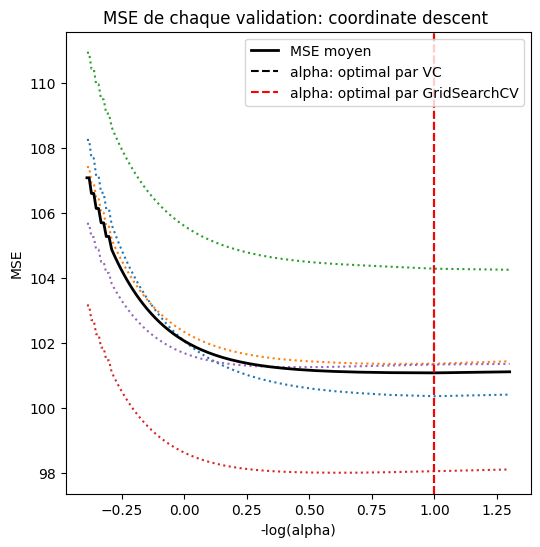

MSE= 95.71402642026344
R2= 0.6945192060740062


'plt.plot(prev,y_chol_test,"o", alpha=0.3)\nplt.xlabel(u"O3 Prédite")\nplt.ylabel("O3 observee")\nplt.show()\n\nplt.plot(prev,y_chol_test-prev,"o", alpha=0.3)\nplt.xlabel(u"Prédites")\nplt.ylabel(u"Résidus")\nplt.hlines(0,40,220)\nplt.show()'

In [ ]:
# grille de valeurs du paramètre alpha à optimiser

param=[{"alpha":[0.05,0.1,0.2,0.3,0.4,0.5,1,2,3]}]
regLasso = GridSearchCV(linear_model.Lasso(), param,cv=5,n_jobs=-1)
regLassOpt=regLasso.fit(X_chol_train, y_chol_train)

### paramètre optimal

# Méthode 1 : on peut accéder directement au meilleur paramètre
regLassOpt.best_params_["alpha"]
print("Meilleur R2 = %f, Meilleur paramètre = %s" % (regLassOpt.best_score_,regLassOpt.best_params_))

# Méthode 2 : on peut aussi accéder à tous les résultats de la validation croisée
model = LassoCV(cv=5, alphas=np.array(range(1,50,1))/20.,n_jobs=-1,random_state=13).fit(X_chol_train, y_chol_train)
m_log_alphas = -np.log10(model.alphas_)
plt.figure()
# ymin, ymax = 2300, 3800
plt.plot(m_log_alphas, model.mse_path_, ':')
plt.plot(m_log_alphas, model.mse_path_.mean(axis=-1), 'k',
         label='MSE moyen', linewidth=2)
plt.axvline(-np.log10(model.alpha_), linestyle='--', color='k',
            label='alpha: optimal par VC')
plt.axvline(-np.log10(regLassOpt.best_params_["alpha"]), linestyle='--', color='r',
            label='alpha: optimal par GridSearchCV')
# on pourrait aussi ajouter 1*l'écart type de l'erreur pour avoir une pénalité plus forte
plt.legend()
plt.xlabel('-log(alpha)')
plt.ylabel('MSE')
plt.title('MSE de chaque validation: coordinate descent ')
plt.show()


# graphes observations vs prédictions et graphe résidus
prev=regLassOpt.predict(X_chol_test)
print("MSE=",mean_squared_error(prev,y_chol_test))
print("R2=",r2_score(y_chol_test,prev))

"""plt.plot(prev,y_chol_test,"o", alpha=0.3)
plt.xlabel(u"O3 Prédite")
plt.ylabel("O3 observee")
plt.show()

plt.plot(prev,y_chol_test-prev,"o", alpha=0.3)
plt.xlabel(u"Prédites")
plt.ylabel(u"Résidus")
plt.hlines(0,40,220)
plt.show()"""




In [25]:
pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

pipeline_reglin = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])


param_grid_log = [
    {
        "model__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag"],
        "model__penalty": ["l2"],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100]
    },
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100]
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2", "elasticnet"],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100],
        "model__l1_ratio": np.linspace(0, 1, 10)   # only used for elasticnet
    },
    {
        "model__solver": ["saga", "lbfgs", "newton-cg", "newton-cholesky"],
        "model__penalty": [None],
        "model__C": [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 1, 10, 100]
    }
]

param_grid_reg = [
    {
        "model": [Ridge()],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [Lasso(max_iter=5000)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [ElasticNet(max_iter=5000)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "model": [LinearRegression()]
    }
]

grid_log = GridSearchCV(
    pipeline_log,
    param_grid=param_grid_log,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_reglin = GridSearchCV(
    pipeline_reglin,
    param_grid=param_grid_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_log.fit(X_heart_train, y_heart_train)
grid_reglin.fit(X_chol_train, y_chol_train)

print("Best parameters:", grid_log.best_params_)
print("Best CV AUC:", grid_log.best_score_)

print("Best parameters:", grid_reglin.best_params_)
print("Best CV MSE:", grid_reglin.best_score_)


c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters: {'model__C': 0.03, 'model__l1_ratio': np.float64(0.6666666666666666), 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
Best CV AUC: 0.8071620394558601
Best parameters: {'model': Lasso(max_iter=5000), 'model__alpha': 0.1}
Best CV MSE: -10.053563389511046


HEART DISEASE : The best penalized model is the one with ElasticNet penalization with the C parameter tuned at 0.03 and using the saga solver.
CHOLESTEROL LEVEL : The best penalized model is the the one with Lasso penalization with the `alpha` parameter tuned at 0.1.

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

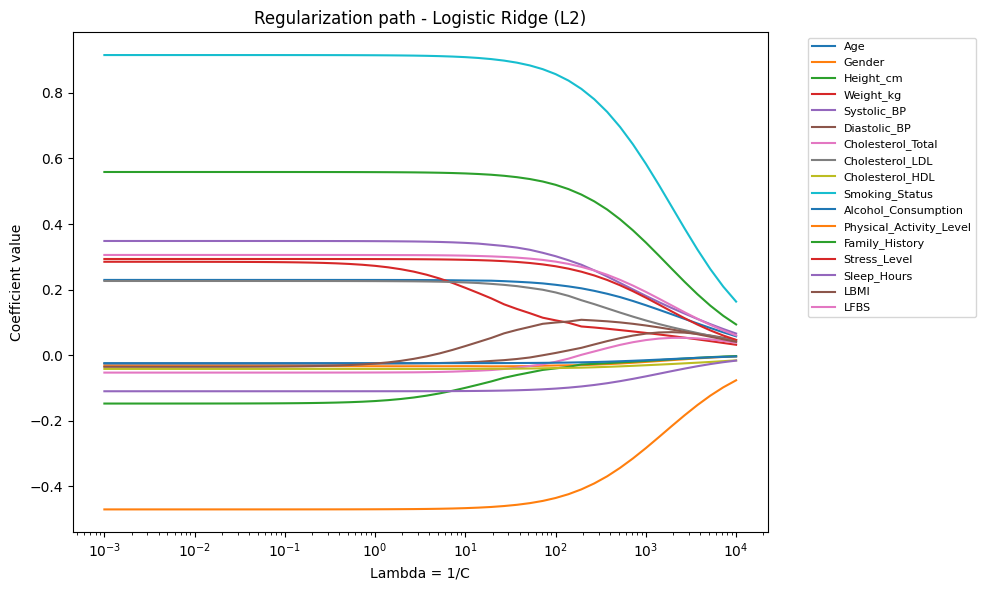

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rat

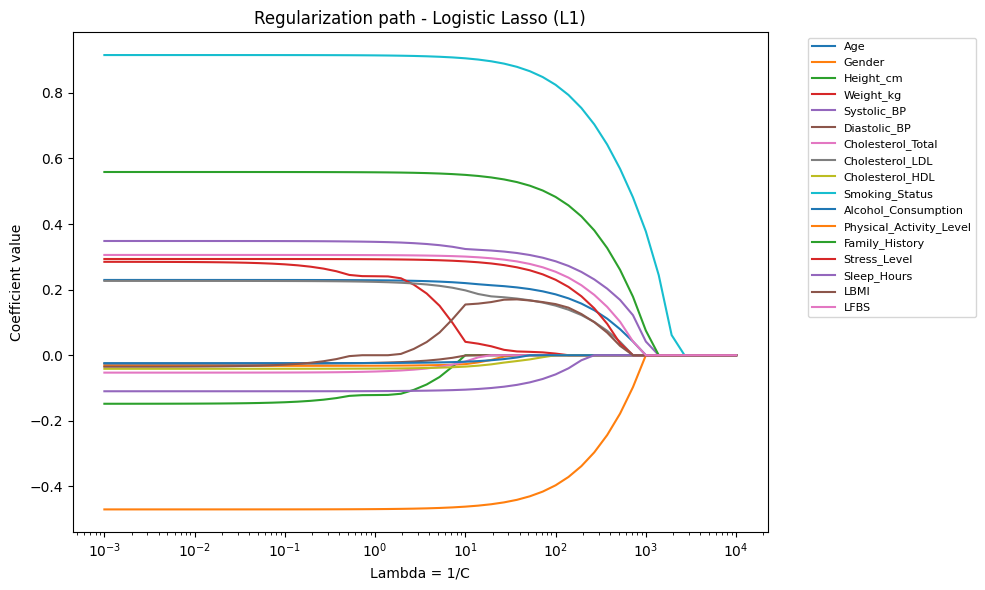

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_rat

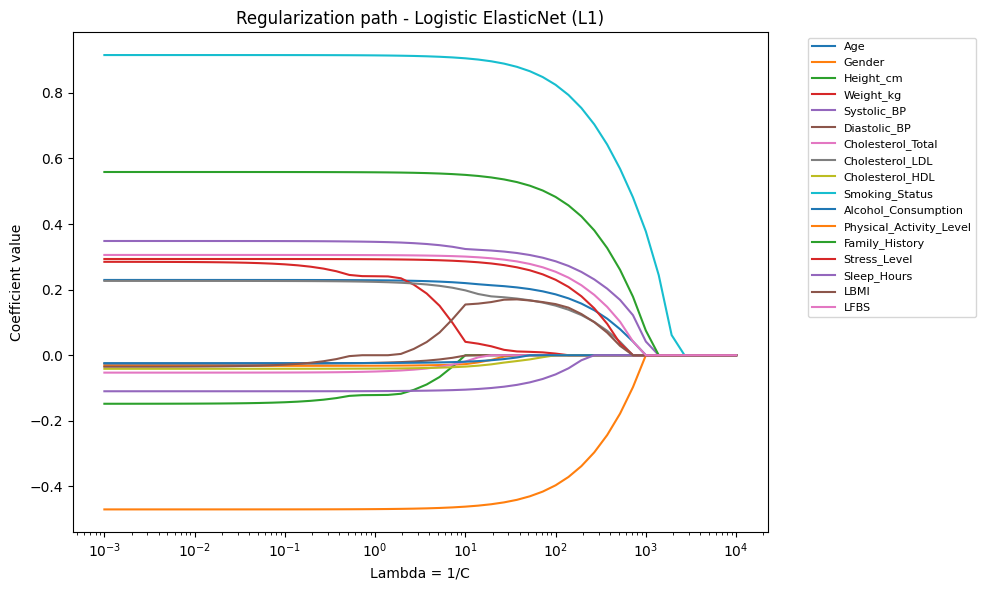

In [ ]:
C_values = np.logspace(-4, 3, 50)   # from strong to weak regularization
lambda_values = 1 / C_values        # equivalent inverse regularization scale

# RIDGE logistic path (L2)

coef_ridge = []
feature_names = X_heart.columns

for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_ridge.append(model.coef_[0])

coef_ridge = np.array(coef_ridge)

plt.figure(figsize=(10, 6))
for i in range(coef_ridge.shape[1]):
    plt.plot(lambda_values, coef_ridge[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic Ridge (L2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# LASSO logistic path (L1)

coef_lasso = []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_lasso.append(model.coef_[0])

coef_lasso = np.array(coef_lasso)

plt.figure(figsize=(10, 6))
for i in range(coef_lasso.shape[1]):
    plt.plot(lambda_values, coef_lasso[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic Lasso (L1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ELASTICNET logistic path (balanced L1 + L2)

coef_elasticnet = []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train, y_heart_train)
    coef_elasticnet.append(model.coef_[0])

coef_elasticnet = np.array(coef_elasticnet)

plt.figure(figsize=(10, 6))
for i in range(coef_elasticnet.shape[1]):
    plt.plot(lambda_values, coef_elasticnet[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Coefficient value")
plt.title("Regularization path - Logistic ElasticNet (L1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

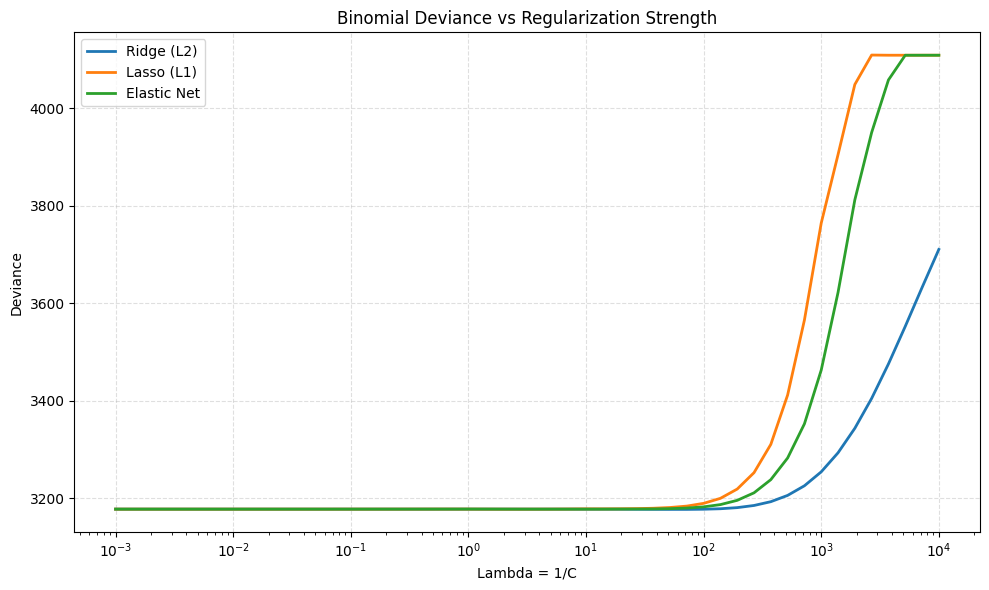

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

# Scale data
scaler = StandardScaler()
X_heart_train_scaled = scaler.fit_transform(X_heart_train)
X_heart_test_scaled = scaler.transform(X_heart_test)

# Regularization grid
C_values = np.logspace(-4, 3, 50)   # weak -> strong in sklearn sense
lambda_values = 1 / C_values        # more intuitive penalization scale

# Containers
deviance_ridge = []
deviance_lasso = []
deviance_elasticnet = []

# ---------- RIDGE ----------
for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train_scaled, y_heart_train)
    probs = model.predict_proba(X_heart_test_scaled)[:, 1]
    
    # Binomial deviance = 2 * log-loss * n
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_ridge.append(dev)

# ---------- LASSO ----------
for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train_scaled, y_heart_train)
    probs = model.predict_proba(X_heart_test_scaled)[:, 1]
    
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_lasso.append(dev)

# ---------- ELASTIC NET ----------
for C in C_values:
    model = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,   # 50% L1, 50% L2
        C=C,
        max_iter=5000,
        random_state=42
    )
    model.fit(X_heart_train_scaled, y_heart_train)
    probs = model.predict_proba(X_heart_test_scaled)[:, 1]
    
    dev = 2 * log_loss(y_heart_test, probs, normalize=False)
    deviance_elasticnet.append(dev)

# ---------- PLOT ----------
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, deviance_ridge, label="Ridge (L2)", linewidth=2)
plt.plot(lambda_values, deviance_lasso, label="Lasso (L1)", linewidth=2)
plt.plot(lambda_values, deviance_elasticnet, label="Elastic Net", linewidth=2)

plt.xscale("log")
plt.xlabel("Lambda = 1/C")
plt.ylabel("Deviance")
plt.title("Binomial Deviance vs Regularization Strength")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### Conclusion 

Let us find the best models for predicting the risk of heart disease and cholesterol level : with or without variable selection and penalization.

In [28]:
pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000, C=0.01))])

pipeline_variable_selection = Pipeline([
    ('scaler', StandardScaler()),
    ('logi', LogisticRegression(max_iter=5000))
])

pipeline_penalty = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'))
])

pipeline_penalty_variable_selection = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'))
])

X_heart_train_BIC = X_heart_train[stepwise_bic_FB(X_heart_train, y_heart_train, sm.Logit)]
scores_simplistic = cross_val_score(pipeline, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
scores_variable_selection = cross_val_score(pipeline_variable_selection, X_heart_train_BIC, y_heart_train, cv=5, scoring="roc_auc")
scores_penalty = cross_val_score(pipeline_penalty, X_heart_train, y_heart_train, cv=5, scoring="roc_auc")
scores_penalty_variable_selection = cross_val_score(pipeline_penalty_variable_selection, X_heart_train_BIC, y_heart_train, cv=5, scoring="roc_auc")

print("Mean CV AUC (Simplistic):", scores_simplistic.mean())
print("Mean CV AUC (Variable Selection):", scores_variable_selection.mean())
print("Mean CV AUC (Penalty):", scores_penalty.mean())
print("Mean CV AUC (Penalty + Variable Selection):", scores_penalty_variable_selection.mean())

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

Mean CV AUC (Simplistic): 0.807000651808225
Mean CV AUC (Variable Selection): 0.7954631290416845
Mean CV AUC (Penalty): 0.807151448451535
Mean CV AUC (Penalty + Variable Selection): 0.7954958874047875


c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

The best linear model for the heart disease risk prediction is therefore the logistic regression without penalization nor variable selection, which gives us a 0.80760 AUC score. It is important to mention that we almost get the same performance for the other cases, with less than a 0.01 difference, so the best strategy is to take the simplest model possible.

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ra

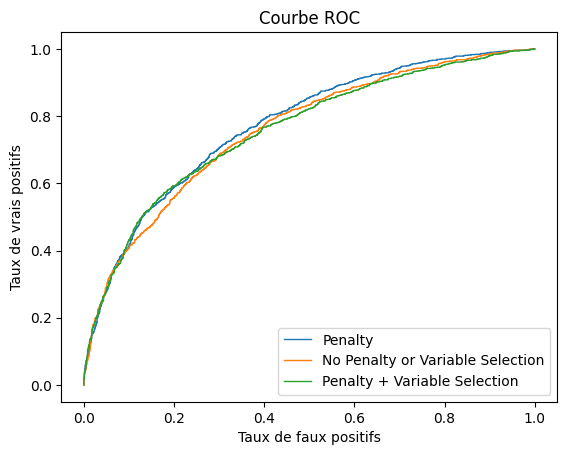

In [29]:
from sklearn.metrics import roc_curve

param=[{"C":[1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train, y_heart_train)
probas_ = LogisticRegression(penalty="elasticnet", solver="saga",
                    C=logitOpt.best_params_['C']).fit(X_heart_train, y_heart_train).predict_proba(X_heart_test)
fpr_pen, tpr_pen, thresholds_pen = roc_curve(y_heart_test, probas_[:,1])

logit = GridSearchCV(LogisticRegression(penalty=None), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train, y_heart_train)
probas_ = LogisticRegression(penalty=None,
                    C=logitOpt.best_params_['C']).fit(X_heart_train, y_heart_train).predict_proba(X_heart_test)
fpr_none, tpr_none, thresholds_none = roc_curve(y_heart_test, probas_[:,1])

logit = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42,C=0.03,solver='saga',l1_ratio=0.5,penalty='elasticnet'), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(X_heart_train[selected_variables_BIC_heart], y_heart_train)
probas_ = LogisticRegression(penalty="elasticnet", solver="saga",
                    C=logitOpt.best_params_['C']).fit(X_heart_train[selected_variables_BIC_heart], y_heart_train).predict_proba(X_heart_test[selected_variables_BIC_heart])
fpr_pen_var, tpr_pen_var, thresholds_pen_var = roc_curve(y_heart_test, probas_[:,1])




plt.plot(fpr_pen, tpr_pen, lw=1)
plt.plot(fpr_none, tpr_none, lw=1)
plt.plot(fpr_pen_var, tpr_pen_var, lw=1)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(['Penalty', 'No Penalty or Variable Selection', 'Penalty + Variable Selection'], loc='lower right')
plt.show()

From the graph we would say that the best strategy is taking the model with only the penalty, which is contradictory with what we just had found!

In [30]:
pipeline = Pipeline([("scaler", StandardScaler()),("model", LinearRegression())])

pipeline_variable_selection = Pipeline([
    ('scaler', StandardScaler()),
    ('logi', LinearRegression())
])

pipeline_penalty = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])

pipeline_penalty_variable_selection = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])

X_chol_train_BIC = X_chol_train[stepwise_bic_FB(X_chol_train, y_chol_train, sm.OLS)]
scores_simplistic = cross_val_score(pipeline, X_chol_train, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_variable_selection = cross_val_score(pipeline_variable_selection, X_chol_train_BIC, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_penalty = cross_val_score(pipeline_penalty, X_chol_train, y_chol_train, cv=5, scoring="neg_mean_squared_error")
scores_penalty_variable_selection = cross_val_score(pipeline_penalty_variable_selection, X_chol_train_BIC, y_chol_train, cv=5, scoring="neg_mean_squared_error")

print("Mean CV MSE (Simplistic):", -scores_simplistic.mean())
print("Mean CV MSE (Variable Selection):", -scores_variable_selection.mean())
print("Mean CV MSE (Penalty):", -scores_penalty.mean())
print("Mean CV MSE (Penalty + Variable Selection):", -scores_penalty_variable_selection.mean())

Mean CV MSE (Simplistic): 101.24980279220014
Mean CV MSE (Variable Selection): 101.06408165130382
Mean CV MSE (Penalty): 101.0840387487148
Mean CV MSE (Penalty + Variable Selection): 101.07394492921765


The best linear model for the cholesterol level prediction is therefore the linear regression without penalization nor variable selection, which gives us a 101.02 MSE score. It is important to mention that we almost get the same performance for the other cases, with less than a difference of 1, so the best strategy is to take the simplest model possible.

####### TO FINISH - PLOTS NEEDED? 
In both plots, we observe how the different coefficients decrease when the regularization increases. Lasso can be used to select a smaller subset of predictors, as it includes variable selection by putting a few coefficients down to zero, while ridge keeps all predictors but shrinks them never reaching zero.

## 2. SVR/SVM

In this section, we are going to be using support vectors to make our predictions, SVM for `Heart_Disease_Risk` and SVR for `Cholestrol_LDL`.

For that matter, we will be tuning our parameters `C` and `gamma` through a cross-validation grid.

We will normalize our data before operating SVM, since this model is very sensitive to the scale of our data. Therefore we will standarize our variables to ensure that they all contribute in a comparable way to the distance calculus. This increases the stability of our model.

In [31]:
X_heart_train_scaled = StandardScaler().fit_transform(X_heart_train)
X_chol_train_scaled = StandardScaler().fit_transform(X_chol_train)

param_heart = {
    "C": [0.01, 0.05, 0.1],
    "gamma": [0.01, 0.03, 0.05],
    "kernel": ["rbf", "linear"]
}

param_chol = {
    "C": [0.01, 0.05, 0.1],
    "gamma": [0.01, 0.03, 0.05],
    "epsilon": [0.01, 0.03, 0.05],
    "kernel": ["rbf", "linear"]
}

svm_heart= GridSearchCV(SVC(),param_heart,cv=2,n_jobs=-1)
svmOpt_heart=svm_heart.fit(X_heart_train_scaled, y_heart_train)

svm_chol= GridSearchCV(SVR(),param_chol,cv=2,n_jobs=-1)
svmOpt_chol=svm_chol.fit(X_chol_train_scaled, y_chol_train)

# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt_heart.best_score_,svmOpt_heart.best_params_))
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt_chol.best_score_,svmOpt_chol.best_params_))

Meilleur score = 0.273250, Meilleur paramètre = {'C': 0.05, 'gamma': 0.01, 'kernel': 'rbf'}
Meilleur score = 0.315826, Meilleur paramètre = {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'linear'}


In [32]:
# erreur de prévision sur le test
print(f"Test error (Heart): {1 - svmOpt_heart.score(X_heart_test, y_heart_test)}")
print(f"Test error (Cholesterol): {1 - svmOpt_chol.score(X_chol_test, y_chol_test)}")

c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


Test error (Heart): 0.5646666666666667


c:\Users\lenovoyoga914\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


Test error (Cholesterol): 33002.32006856916


In [33]:
# scale test data with the SAME scaler used on train
X_heart_test_scaled = scaler.transform(X_heart_test)
X_chol_test_scaled = scaler.transform(X_chol_test)

# prediction
y_heart_pred = svmOpt_heart.predict(X_heart_test_scaled)
y_chol_pred = svmOpt_chol.predict(X_chol_test_scaled)

# full confusion table
table_heart = pd.crosstab(
    # we have to convert the predictions and the true labels to categorical variables with the same categories to avoid errors in the crosstab function
    # otherwise we had one of the two categories missing in the predictions and it was not able to create the table
    pd.Categorical(y_heart_pred, categories=[0, 1]),
    pd.Categorical(y_heart_test, categories=[0, 1]),
    rownames=["Predicted"],
    colnames=["Actual"]
)

table_chol = pd.crosstab(
    pd.Categorical(y_chol_pred, categories=[0, 1]),
    pd.Categorical(y_chol_test, categories=[0, 1]),
    rownames=["Predicted"],
    colnames=["Actual"]
)

print("Confusion Matrix SVM: Heart Disease Risk")
print(table_heart)

print("\nConfusion Matrix SVM: Cholesterol Level")
print(table_chol)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Cholesterol_LDL


In [ ]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
treeG=DecisionTreeClassifier(max_depth=treeOpt.best_params_['max_depth'])
treeG.fit(Xr_train,Yb_train)
plot_tree(treeG,feature_names=dfC.columns.tolist());
plt.show()


In [ ]:
from sklearn.svm import SVR

X_chol_train_scaled = StandardScaler().fit_transform(X_chol_train)


param = {
    "C": [0.01, 0.5, 1],
    "gamma": [0.01, 0.03, 0.05],
    "epsilon": [0.01, 0.03, 0.05],
    "kernel": ["rbf", "linear"]
}

svm= GridSearchCV(SVR(),param,cv=3,n_jobs=-1)
svmOpt=svm.fit(X_chol_train_scaled, y_chol_train)

# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt.best_score_,svmOpt.best_params_))

## 3. Arbre Optimal

## 4. Forêt aléatoire

## 5. Boosting

## 6. Neural Networks